# 04 - XAI, shift entre particiones y analisis de errores

## Resumen amplio

Este notebook audita el modelo principal. En un dominio juridico no basta con reportar F1: hay que saber que senales textuales empujan predicciones, donde se concentra el error y si la distribucion cambia entre particiones.

La explicabilidad se aborda globalmente con coeficientes de regresion logistica y localmente con LIME. Las explicaciones describen comportamiento del modelo, no causalidad juridica. El drift se formula como **shift entre splits**, porque no hay ano oficial de sentencia en el dataset cargado.

## Indice

1. Carga o generacion de predicciones.
2. XAI global por coeficientes.
3. XAI local con LIME.
4. Probe de fidelidad.
5. Shift de etiquetas.
6. Rendimiento por split.
7. Errores FP/FN.
8. Figuras y tablas finales.


![Esquema especifico generado con Image Gen](artifacts/figures/generated/notebook_04_audit.png)

**Lectura del esquema.** La imagen resume la auditoria: pesos globales, explicaciones locales, shift entre splits y separacion de falsos positivos y falsos negativos. La imagen es conceptual; las cifras y conclusiones se calculan en las celdas del notebook con datos reales.


In [1]:
import json, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import project_utils as pu
warnings.filterwarnings('ignore')
pu.configure(); sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 180)


## 1. Preparacion de artefactos

Si faltan predicciones, se generan con el mismo helper del notebook 02. Esto permite ejecutar esta libreta directamente.


In [2]:
import joblib
from sklearn.metrics import f1_score, hamming_loss

pu.materialize_database(force=False)
vectorizer_path = pu.MODELS / 'notebook_tfidf_vectorizer.joblib'
logreg_path = pu.MODELS / 'notebook_logreg_ovr.joblib'
thresholds_path = pu.MODELS / 'notebook_thresholds.json'
missing = [str(path) for path in [vectorizer_path, logreg_path, thresholds_path] if not path.exists()]
if missing:
    raise FileNotFoundError(
        'Faltan artefactos del notebook 02. Ejecuta primero 02_modelado_multilabel.ipynb. Faltan: ' + ', '.join(missing)
    )

vectorizer = joblib.load(vectorizer_path)
logreg = joblib.load(logreg_path)
threshold_payload = json.loads(thresholds_path.read_text(encoding='utf-8'))
thresholds = np.array([threshold_payload['thresholds'][code] for code in pu.ARTICLE_CODES], dtype=float)
pred = pu.load_predictions('notebook_threshold_tuned')
if pred.empty:
    raise RuntimeError('No hay predicciones en SQLite. Ejecuta primero el notebook 02 para generarlas.')

print(f'Predicciones cargadas: {pred.shape[0]} casos')
display(pred[['case_id', 'split']].head())


Predicciones cargadas: 11000 casos


,case_id,split
0,ecthr_task_b_test_000000,test
1,ecthr_task_b_test_000001,test
2,ecthr_task_b_test_000002,test
3,ecthr_task_b_test_000003,test
4,ecthr_task_b_test_000004,test


## 2. XAI global por coeficientes

Un peso positivo alto aumenta el score del articulo cuando el termino aparece con TF-IDF alto. Esto permite auditar si el modelo aprende senales juridicamente plausibles.


In [3]:
feature_names = np.array(vectorizer.get_feature_names_out())
rows=[]
for label_idx, estimator in enumerate(logreg.estimators_):
    coefs=estimator.coef_.ravel(); pos=np.argsort(coefs)[-15:][::-1]; neg=np.argsort(coefs)[:15]
    for rank, idx in enumerate(pos, start=1): rows.append({'article_code':pu.ARTICLE_CODES[label_idx],'direction':'positive','rank':rank,'term':feature_names[idx],'weight':float(coefs[idx])})
    for rank, idx in enumerate(neg, start=1): rows.append({'article_code':pu.ARTICLE_CODES[label_idx],'direction':'negative','rank':rank,'term':feature_names[idx],'weight':float(coefs[idx])})
global_terms=pd.DataFrame(rows); global_terms.to_csv(pu.METRICS/'xai_global_terms.csv', index=False); display(global_terms.head(40))


,article_code,direction,rank,term,weight
0,2,positive,1,death,4.844247
1,2,positive,2,the death,2.953100
2,2,positive,3,son,2.520602
3,2,positive,4,autopsy,2.470425
4,2,positive,5,died,2.443594
5,2,positive,6,the investigation,2.164215
6,2,positive,7,death of,2.160922
7,2,positive,8,investigation,2.119891
8,2,positive,9,shot,2.032355
9,2,positive,10,killed,2.019883


### Como leer estos terminos

La columna `direction = positive` no significa que el termino sea "bueno" ni que el derecho valore positivamente esa palabra. Significa **signo positivo del coeficiente**: cuando ese termino aparece con peso TF-IDF alto, el score del articulo aumenta. Por ejemplo, `death` es un termino positivo esperable para el articulo 2 porque ese articulo trata el derecho a la vida; `hearing`, `court` o `appeal` suelen aparecer asociados al articulo 6 porque remiten a garantias procesales. Esta interpretacion es estadistica, no causal ni doctrinal: el modelo aprende correlaciones del dataset.

Tambien hay que vigilar terminos demasiado genericos. Si aparece una palabra comun con peso alto, puede indicar que el vectorizador esta capturando una regularidad de redaccion, no necesariamente un concepto juridico robusto. Por eso se combina esta lectura global con LIME local y analisis de errores.


### Ejemplos de lectura de pesos globales

Los terminos con peso positivo son palabras o bigramas que aumentan el score del articulo correspondiente cuando aparecen con TF-IDF alto. No significan que el articulo este probado juridicamente; indican asociacion aprendida por el modelo.


In [ ]:
examples_by_article = []
for article in ['2', '6', '10']:
    terms = global_terms[(global_terms['article_code'] == article) & (global_terms['direction'] == 'positive')].head(5)['term'].tolist()
    examples_by_article.append(f"- Articulo {article}: " + ', '.join(f'`{t}`' for t in terms))
    
examples_by_article

Estos ejemplos se deben contrastar con casos concretos. Si un termino parece demasiado generico, puede ser una senal de estilo de redaccion y no una razon juridica robusta. Por eso el notebook combina coeficientes globales, LIME local y analisis de errores.

## 3. XAI local con LIME

LIME perturba un texto real y aproxima localmente el comportamiento del modelo para una etiqueta concreta. Se guardan HTMLs para inspeccion humana.


In [5]:
try:
    from lime.lime_text import LimeTextExplainer
    lime_available=True
except Exception as exc:
    lime_available=False; print('LIME no disponible:', exc)
frames = pu.train_validation_test_frames(); test_df = frames['test']
def predict_for_lime(texts):
    """Funcion puente entre LIME y el modelo principal.

    Entrada:
        texts: lista de textos perturbados que LIME genera alrededor de un caso.

    Salida:
        Matriz `(n_textos, n_articulos)` con probabilidades de clase positiva.
        LIME usa estas probabilidades para aproximar localmente que palabras
        aumentan o reducen el score de un articulo concreto.
    """
    return pu.as_probability_matrix(logreg.predict_proba(vectorizer.transform(list(texts))))
lime_rows=[]
if lime_available:
    explainer=LimeTextExplainer(class_names=pu.ARTICLE_CODES, random_state=pu.SEED)
    for item in pred[pred['split']=='test'].head(5).itertuples(index=False):
        scores=np.array(item.scores); label_idx=int(np.argmax(scores)); text=test_df.loc[test_df['case_id']==item.case_id,'text_full'].iloc[0]
        exp=explainer.explain_instance(text, predict_for_lime, labels=[label_idx], num_features=10, num_samples=800)
        out=pu.REPORTS/f'notebook_lime_{item.case_id}_{label_idx}.html'; exp.save_to_file(str(out))
        lime_rows.append({'case_id':item.case_id,'label_idx':label_idx,'article_code':pu.ARTICLE_CODES[label_idx],'positive_prob':float(scores[label_idx]),'artifact_path':str(out),'explanation_terms_json':json.dumps(exp.as_list(label=label_idx))})
lime_summary=pd.DataFrame(lime_rows); lime_summary.to_csv(pu.METRICS/'xai_lime_summary.csv', index=False); display(lime_summary)


,case_id,label_idx,article_code,positive_prob,artifact_path,explanation_terms_json
0,ecthr_task_b_test_000000,6,10,0.949734,C:\Users\jordi\Documents\UNI\proyecto-aprendizaje-avanzado\artifacts\reports\notebook_lime_ecthr_task_b_test_000000_6.html,"[[""journalist"", 0.06727494751948287], [""press"", 0.05228377357415672], [""broadcasting"", 0.04874521755240301], [""journalists"", 0.04855025071822175], [""reality"", 0.043713898092571..."
1,ecthr_task_b_test_000001,3,6,0.607172,C:\Users\jordi\Documents\UNI\proyecto-aprendizaje-avanzado\artifacts\reports\notebook_lime_ecthr_task_b_test_000001_3.html,"[[""the"", 0.05995919048959363], [""company"", 0.03466783058175194], [""proceedings"", 0.03338035052590327], [""that"", -0.025297192827628667], [""his"", -0.02446354979479209], [""claim"",..."
2,ecthr_task_b_test_000002,3,6,0.624944,C:\Users\jordi\Documents\UNI\proyecto-aprendizaje-avanzado\artifacts\reports\notebook_lime_ecthr_task_b_test_000002_3.html,"[[""2013"", -0.06220674805879522], [""Administrative"", 0.0490680129474593], [""2011"", -0.04787795347504391], [""Court"", 0.047362506065046404], [""Supreme"", 0.03987886998946534], [""ju..."
3,ecthr_task_b_test_000003,3,6,0.790289,C:\Users\jordi\Documents\UNI\proyecto-aprendizaje-avanzado\artifacts\reports\notebook_lime_ecthr_task_b_test_000003_3.html,"[[""the"", 0.08922205669265934], [""hearing"", 0.0536920206416388], [""absence"", 0.04849233061463493], [""lawyer"", 0.040664890247493354], [""company"", 0.03390927803461954], [""appeal"",..."
4,ecthr_task_b_test_000004,1,3,0.965156,C:\Users\jordi\Documents\UNI\proyecto-aprendizaje-avanzado\artifacts\reports\notebook_lime_ecthr_task_b_test_000004_1.html,"[[""officers"", 0.08029267233883046], [""medical"", 0.07352740869891107], [""arrest"", 0.061540736803587584], [""his"", 0.05835123058737814], [""injuries"", 0.05390669730185932], [""beate..."


## 4. Probe de fidelidad local

Se elimina un termino positivo de una explicacion LIME y se mide si baja el score. No prueba causalidad juridica, pero comprueba alineacion basica entre explicacion y modelo.


In [6]:
fidelity_rows=[]
if not lime_summary.empty:
    row=lime_summary.iloc[0]; terms=json.loads(row['explanation_terms_json']); positive_terms=[t for t,w in terms if w>0 and len(t)>2]
    if positive_terms:
        term=positive_terms[0]; text=test_df.loc[test_df['case_id']==row['case_id'],'text_full'].iloc[0]; label_idx=int(row['label_idx'])
        original=predict_for_lime([text])[0,label_idx]
        perturbed=predict_for_lime([re.sub(re.escape(term),' ',text,flags=re.IGNORECASE)])[0,label_idx]
        fidelity_rows.append({'case_id':row['case_id'],'article_code':row['article_code'],'removed_term':term,'original_score':float(original),'score_without_term':float(perturbed),'delta':float(original-perturbed)})
fidelity=pd.DataFrame(fidelity_rows); fidelity.to_csv(pu.METRICS/'xai_fidelity_probe.csv', index=False); display(fidelity)


,case_id,article_code,removed_term,original_score,score_without_term,delta
0,ecthr_task_b_test_000000,10,journalist,0.949734,0.933753,0.015981


## 5. Shift de etiquetas y rendimiento

Se compara cada split contra train con Jensen-Shannon, L1 y coseno. Luego se comparan metricas por split para detectar sobreajuste o cambios de dificultad.


In [7]:
cases, labels, articles = pu.load_cases_labels(); y = pu.multilabel_matrix(labels, cases['case_id'], articles)
train_dist = y.loc[cases[cases['split']=='train']['case_id']].sum(axis=0).to_numpy(dtype=float)
shift_rows=[]
for split in ['validation','test']:
    split_dist=y.loc[cases[cases['split']==split]['case_id']].sum(axis=0).to_numpy(dtype=float); p=train_dist/train_dist.sum(); q=split_dist/split_dist.sum()
    shift_rows.append({'target_split':split,'js_divergence':pu.js_divergence(p,q),'l1_distance':float(np.abs(p-q).sum()),'cosine_similarity':float(np.dot(p,q)/(np.linalg.norm(p)*np.linalg.norm(q)))})
shift=pd.DataFrame(shift_rows); shift.to_csv(pu.METRICS/'drift_label_shift_by_split.csv', index=False)
perf_rows=[]
for split, group in pred.groupby('split'):
    perf_rows.append(pu.metric_table(np.array(group['y_true'].tolist()), np.array(group['y_pred'].tolist()), split, 'tfidf_logreg_threshold_tuned'))
perf=pd.DataFrame(perf_rows).sort_values('split'); perf.to_csv(pu.METRICS/'drift_performance_by_split.csv', index=False)
base=perf[perf['split']=='validation'].iloc[0]; paper_drift=shift.copy()
for metric in ['macro_f1','micro_f1','hamming_loss']:
    lookup=perf.set_index('split')[metric]; paper_drift[f'delta_{metric}']=paper_drift['target_split'].map(lambda s: float(lookup[s]-base[metric]))
paper_drift.to_csv(pu.METRICS/'paper_drift_table.csv', index=False)
display(shift); display(perf); display(paper_drift)


,target_split,js_divergence,l1_distance,cosine_similarity
0,validation,0.017336,0.278045,0.958946
1,test,0.025531,0.320362,0.950533


,model,split,n_cases,macro_f1,micro_f1,hamming_loss
0,tfidf_logreg_threshold_tuned,test,1000,0.713807,0.751799,0.069000
1,tfidf_logreg_threshold_tuned,train,9000,0.876577,0.905152,0.028456
2,tfidf_logreg_threshold_tuned,validation,1000,0.739720,0.774359,0.061600


,target_split,js_divergence,l1_distance,cosine_similarity,delta_macro_f1,delta_micro_f1,delta_hamming_loss
0,validation,0.017336,0.278045,0.958946,0.000000,0.00000,0.0000
1,test,0.025531,0.320362,0.950533,-0.025912,-0.02256,0.0074


## 6. Analisis de errores FP/FN

Un falso negativo puede ocultar un articulo relevante; un falso positivo anade carga de revision. Se calculan ambos por caso.


In [8]:
error_rows=[]
for row in pred.itertuples(index=False):
    true=np.array(row.y_true); predicted=np.array(row.y_pred)
    tp=int(((true==1)&(predicted==1)).sum()); fp=int(((true==0)&(predicted==1)).sum()); fn=int(((true==1)&(predicted==0)).sum())
    error_rows.append({'case_id':row.case_id,'split':row.split,'tp':tp,'fp':fp,'fn':fn,'n_errors':fp+fn,'n_true':int(true.sum()),'n_pred':int(predicted.sum())})
errors=pd.DataFrame(error_rows); patterns=errors.groupby(['split','fp','fn']).size().reset_index(name='n_cases').sort_values(['split','n_cases'], ascending=[True,False]); split_error=errors.groupby('split')[['tp','fp','fn','n_errors']].mean().reset_index()
errors.to_csv(pu.METRICS/'error_analysis_cases.csv', index=False); patterns.to_csv(pu.METRICS/'error_analysis_patterns.csv', index=False); patterns.head(20).to_csv(pu.METRICS/'paper_error_pattern_table.csv', index=False); split_error.to_csv(pu.METRICS/'paper_error_split_table.csv', index=False)
display(split_error); display(patterns.head(20)); worst_test=errors[errors['split']=='test'].sort_values(['n_errors','fn','fp'], ascending=False).head(5); display(worst_test)
if not worst_test.empty: display(pd.DataFrame([pu.summarize_case(worst_test.iloc[0]['case_id'], max_chars=1000)]))


,split,tp,fp,fn,n_errors
0,test,1.045000,0.300000,0.390,0.690000
1,train,1.357778,0.179556,0.105,0.284556
2,validation,1.057000,0.282000,0.334,0.616000


,split,fp,fn,n_cases
0,test,0,0,498
1,test,0,1,180
5,test,1,0,164
6,test,1,1,67
2,test,0,2,48
9,test,2,0,18
7,test,1,2,9
10,test,2,1,4
11,test,3,0,4
3,test,0,3,3


,case_id,split,tp,fp,fn,n_errors,n_true,n_pred
226,ecthr_task_b_test_000226,test,0,0,4,4,4,0
559,ecthr_task_b_test_000559,test,0,0,4,4,4,0
983,ecthr_task_b_test_000983,test,1,0,4,4,5,1
813,ecthr_task_b_test_000813,test,0,1,3,4,3,1
96,ecthr_task_b_test_000096,test,0,3,1,4,1,3


,case_id,task,split,year,n_paragraphs,n_tokens,excerpt,article_codes
0,ecthr_task_b_test_000226,ecthr_task_b,test,None,11,1322,6. The applicant was born in 1958 and lives in Leipzig. 7. On 30 October 2009 the Munich II Public Prosecution Office charged the applicant with coercion to engage in sexual...,"2, 3, 6, 8"


## 7. Figuras y tablas finales

Las figuras combinan interpretabilidad global, errores, shift y rendimiento.


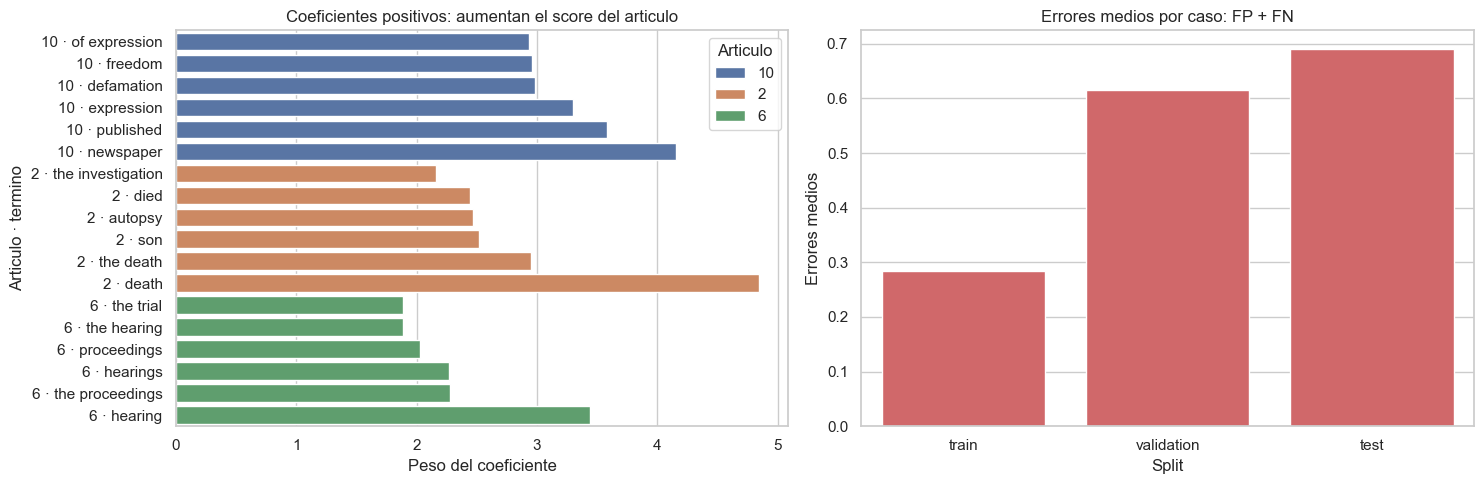

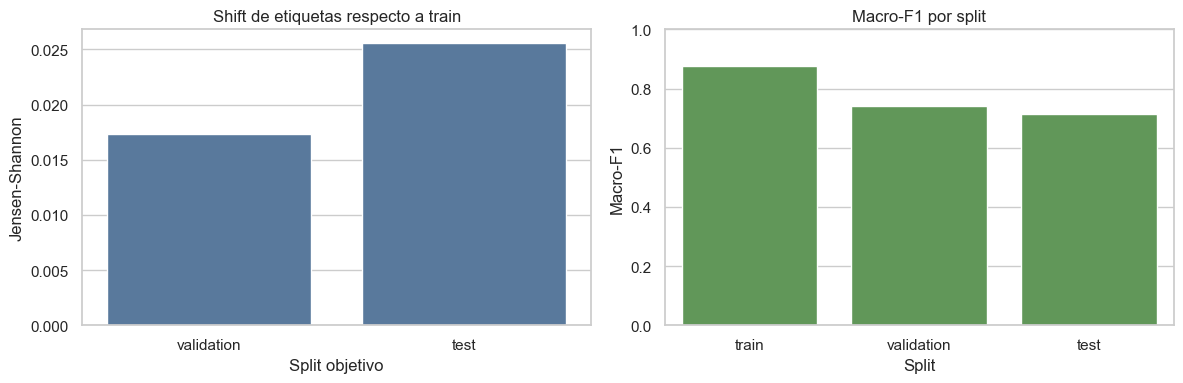

,n_global_labels,n_local_explanations,mean_abs_global_weight,mean_local_positive_prob
0,10,5,1.831876,0.787459


In [9]:
selected_articles = ['2', '6', '10']
term_plot = global_terms[
    (global_terms['direction'] == 'positive')
    & (global_terms['article_code'].isin(selected_articles))
    & (global_terms['rank'] <= 6)
].copy()
term_plot['term_label'] = term_plot['article_code'] + ' · ' + term_plot['term']
term_plot = term_plot.sort_values(['article_code', 'weight'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=term_plot, x='weight', y='term_label', hue='article_code', dodge=False, ax=axes[0])
axes[0].set_title('Coeficientes positivos: aumentan el score del articulo')
axes[0].set_xlabel('Peso del coeficiente')
axes[0].set_ylabel('Articulo · termino')
axes[0].legend(title='Articulo')

sns.barplot(data=split_error, x='split', y='n_errors', order=pu.SPLIT_ORDER, ax=axes[1], color='#e15759')
axes[1].set_title('Errores medios por caso: FP + FN')
axes[1].set_xlabel('Split')
axes[1].set_ylabel('Errores medios')
fig.tight_layout()
fig.savefig(pu.FIGURES / 'fig06_xai_global_local.png', dpi=180)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=shift, x='target_split', y='js_divergence', ax=axes[0], color='#4e79a7')
axes[0].set_title('Shift de etiquetas respecto a train')
axes[0].set_xlabel('Split objetivo')
axes[0].set_ylabel('Jensen-Shannon')

sns.barplot(data=perf, x='split', y='macro_f1', order=pu.SPLIT_ORDER, ax=axes[1], color='#59a14f')
axes[1].set_ylim(0, 1)
axes[1].set_title('Macro-F1 por split')
axes[1].set_xlabel('Split')
axes[1].set_ylabel('Macro-F1')
fig.tight_layout()
fig.savefig(pu.FIGURES / 'fig07_drift_error_distributions.png', dpi=180)
plt.show()

xai_table = pd.DataFrame([{
    'n_global_labels': global_terms['article_code'].nunique(),
    'n_local_explanations': len(lime_summary),
    'mean_abs_global_weight': float(global_terms['weight'].abs().mean()),
    'mean_local_positive_prob': float(lime_summary['positive_prob'].mean()) if not lime_summary.empty else np.nan,
}])
xai_table.to_csv(pu.METRICS / 'paper_xai_table.csv', index=False)
display(xai_table)
